# This file is for visualizing all data needed for the project from the ENTSO-E Transparency Platform (TP)
Library documentation at: https://github.com/EnergieID/entsoe-py
API documentation at: https://documenter.getpostman.com/view/7009892/2s93JtP3F6

The data that is imported and visualized is:
- **ENTSO-E Histroical Actual load and generation SE1 / SE2 / SE3 / SE4 hourly from 2015** (for training, feautre enginnering, testing and evaluting)
- **ENTSO-E Historical day-ahead load forecasts archive of TSO forecasts** (for evaluating)
- **SMHI / ERA5 Historical weather observations Temp · Wind · Irradiance** (for trainging and feature engineering)
- **Open-Meteo Historical Forecast API NWP model output archive from 2017** (for trainging and feature engineering)
- **Open-Meteo Live Forecast API Current NWP model run** (for live version)
- **ENTSO-E Live day-ahead load forecast current TSO forecast published today for tomorrow** (for live version)
- **ENTSO-E Latest actual load real-time measured load per bidding area SE1 to SE4** (for live version)

In [ ]:
#########################################
# ENTSO-E Data from Transparency Platform
#########################################

# Import necessary libraries
from dotenv import load_dotenv
import os
import pandas as pd
from entsoe import EntsoePandasClient   # pip install entsoe-py

# Load the API key from the .env file
load_dotenv()
api_key = os.getenv("ENTSOE_API_KEY")

# Initialize the client with the API key
client = EntsoePandasClient(api_key)

# Define the time range and time zone for data retrieval
start = pd.Timestamp("2024-01-01", tz="Europe/Stockholm")
end   = pd.Timestamp("2024-01-02", tz="Europe/Stockholm")

# Specify the time bidding area for the data retrieval
zones = ["SE_1", "SE_2", "SE_3", "SE_4"]  # Sweden bidding zone 3

# Retrive the load data for Sweden bidding zones from the ENTSO-E API
loads = {}

for zone in zones:
    # Query the load data for the specified zone and time range
    load = client.query_load(zone, start=start, end=end)

    # Convert to timestamp index to UTC
    load.index = load.index.tz_convert("UTC")

    # Store by zone name
    loads[zone] = load



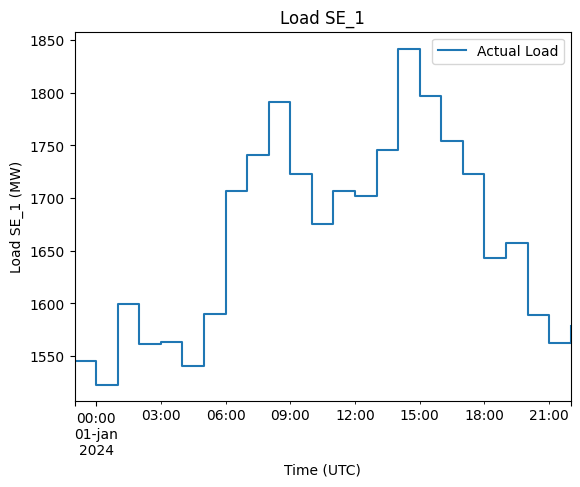

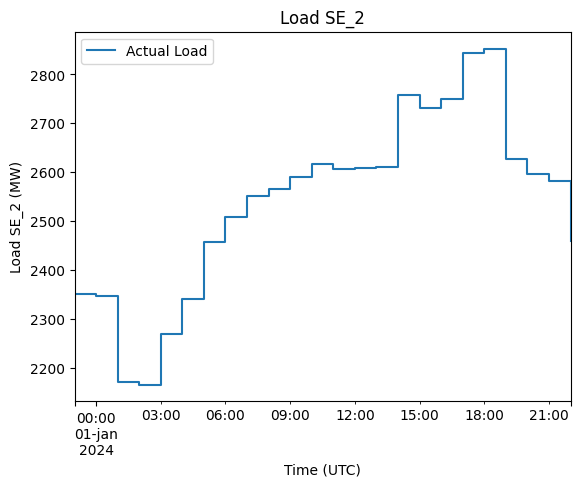

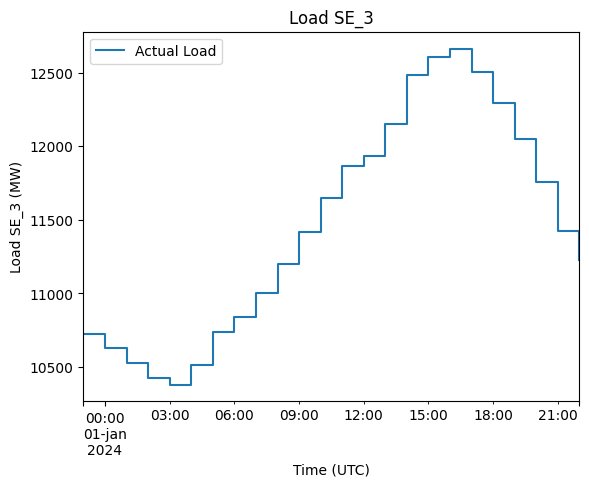

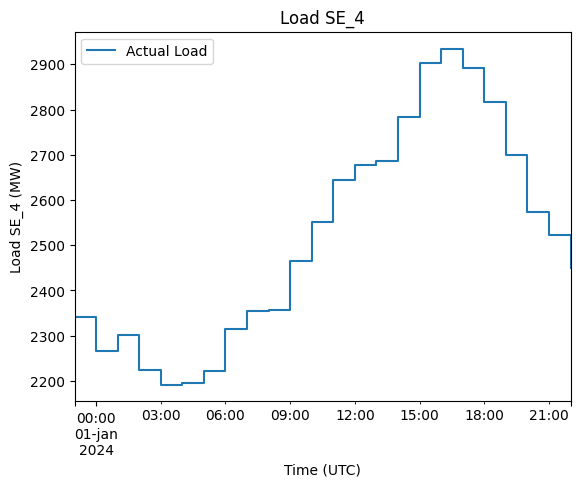

In [ ]:
# Print results using matplotlib
import matplotlib.pyplot as plt

for zone in zones:
    load = loads[zone]
    ax = load.plot(
        title=f"Load {zone}",
        drawstyle="steps-post"
    )
    ax.set_ylabel(f"Load {zone} (MW)")
    ax.set_xlabel("Time (UTC)")
    plt.show()